<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Multi-Crop-Ranking/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Multi‑Crop Ranking — Training & Validation**
This notebook trains and validates the multi‑crop ranking model using **grouped evaluation** to avoid leakage.

### What you get at the end
- A saved, deployable **scikit‑learn Pipeline** (`best_ranking_model.joblib`)
- A saved **per‑crop requirement table** (`crop_requirements_derived.csv`) used during ranking
- Clean evaluation (ROC‑AUC + ranking Precision@5 per scenario)


##**-** Colab setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Install deps (Colab usually has these, but this is safe)
!pip -q install joblib shap scikit-learn pandas numpy matplotlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **1)** Imports

In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## **2)** Load dataset

In [ ]:
# Path handling: works in Colab or local
DATA_PATH = '/content/drive/MyDrive/DSGP/Crop_training_data_FULL_1.csv'
df = pd.read_csv(DATA_PATH)

a= df['suitability_class'].value_counts()
print('Shape:', df.shape)
display(df.head())
print('\n|--- Target distribution ---|\n')
print(a.to_string().replace("\n", "\n  "))

Mounted at /content/drive


## **3)** Basic data audit

In [ ]:
# Check missing values
missing = df.isna().sum().sort_values(ascending=False)
print('Top missing columns:')
print(missing[missing > 0])

# Duplicate rows
print('\n-->''Duplicate rows:', df.duplicated().sum())

Top missing columns:
Series([], dtype: int64)

-->Duplicate rows: 0


## **4)** Define target and features

In [ ]:
#Encode target: Suitable=1, Unsuitable=0
df['target'] = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0})

In [ ]:
# Binary target
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0}).astype(int)

# Drop non-features / unused columns
DROP_COLS = ['suitability_class', 'suitability', 'texture']  # texture is a string version; keep texture_code
X = df.drop(columns=DROP_COLS)

# Columns used as environmental conditions (used to group scenarios and to build user input)
ENV_COLS = [
    'temperature', 'rainfall', 'sunshine_hours',
    'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code'
]

# IMPORTANT: rooting_depth_m behaves like a crop requirement (not an environmental variable).
# We'll still allow it as a model input because it's in the dataset,
# but we DO NOT include it in scenario grouping.
print('X columns ->', list(X.columns))
print('ENV_COLS ->', ENV_COLS)

X columns -> ['crop', 'temperature', 'rainfall', 'sunshine_hours', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'rooting_depth_m', 'texture_code']
ENV_COLS -> ['temperature', 'rainfall', 'sunshine_hours', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code']


## **5)** Create scenario groups (prevents leakage)

In [ ]:
# Group by rounded environmental feature vector.
# This ensures the same (weather+soil) condition doesn't appear in both train and test.
rounded_env = df[ENV_COLS].round(2)
df['scenario_id'] = pd.util.hash_pandas_object(rounded_env, index=False).astype('int64')

groups = df['scenario_id']
print('|-','Unique scenarios ->', groups.nunique(),'-|')

|- Unique scenarios -> 2100 -|


## **6)** Train/test split by scenario

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
g_train, g_test = groups.iloc[train_idx].copy(), groups.iloc[test_idx].copy()

print('|-','Train ->', X_train.shape,'    -|-\t', 'Test ->', X_test.shape,'\t-|')
print('|-','Train scenarios ->', g_train.nunique(),'-|-', '  Test scenarios ->', g_test.nunique(),' -|')

|- Train -> (1680, 11)     -|-	 Test -> (420, 11) 	-|
|- Train scenarios -> 1680 -|-   Test scenarios -> 420  -|


## **7)** Preprocessing pipeline (robust and deployable)
We use a single sklearn `Pipeline` so training and inference use the exact same transforms.

- Numeric: impute median + standardize
- Categorical (`crop`): one-hot encode (handle_unknown='ignore')

In [ ]:
# Identify columns
categorical_cols = ['crop']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)

## **8)** Model candidates + Grid Search (GroupKFold CV)
We use **GroupKFold** to make sure CV folds do not mix the same scenario between train/val.

In [ ]:
cv = GroupKFold(n_splits=5)

candidates = {
    'logreg': (LogisticRegression(max_iter=2000), {
        'model__C': [0.1, 1.0, 10.0],
        'model__class_weight': [None, 'balanced']
    }),
    'rf': (RandomForestClassifier(random_state=42), {
        'model__n_estimators': [300, 600],
        'model__max_depth': [None, 12, 24],
        'model__min_samples_split': [2, 6],
        'model__class_weight': [None, 'balanced_subsample']
    }),
    'svm': (SVC(probability=True), {
        'model__C': [1.0, 10.0],
        'model__gamma': ['scale', 0.1],
        'model__class_weight': [None, 'balanced']
    })
}

search_results = {}
rows = []

for name, (model, params) in candidates.items():
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train, groups=g_train)

    search_results[name] = gs
    rows.append({
        "Model": name,
        "Best ROC-AUC": round(gs.best_score_, 4),
        "Best Params": gs.best_params_
    })

results_df = pd.DataFrame(rows).sort_values("Best ROC-AUC", ascending=False).reset_index(drop=True)

# display nicely in Colab
results_df

,Model,Best ROC-AUC,Best Params
0,rf,0.9408,"{'model__class_weight': None, 'model__max_dept..."
1,svm,0.9313,"{'model__C': 10.0, 'model__class_weight': 'bal..."
2,logreg,0.9192,"{'model__C': 10.0, 'model__class_weight': None}"


## **9)** Model Comparison

In [ ]:
# Comparison: Baseline (default params) vs Tuned (GridSearchCV) on the same held-out test scenarios
baseline_rows = []

for name, (model, _params) in candidates.items():
    # Baseline model: default hyperparameters (same preprocessing)
    base_pipe = Pipeline(steps=[('preprocess', preprocess), ('model', clone(model))])
    base_pipe.fit(X_train, y_train)
    p_base = base_pipe.predict_proba(X_test)[:, 1]
    baseline_rows.append({
        "Model": name,
        "Stage": "Baseline",
        "ROC_AUC": roc_auc_score(y_test, p_base),
        "AUPRC": average_precision_score(y_test, p_base)
    })

    # Tuned model: best estimator from GridSearchCV
    tuned_pipe = search_results[name].best_estimator_
    p_tuned = tuned_pipe.predict_proba(X_test)[:, 1]
    baseline_rows.append({
        "Model": name,
        "Stage": "Tuned",
        "ROC_AUC": roc_auc_score(y_test, p_tuned),
        "AUPRC": average_precision_score(y_test, p_tuned)
    })

compare_df = pd.DataFrame(baseline_rows).sort_values(["Model", "Stage"]).reset_index(drop=True)
display(compare_df)


,Model,Stage,ROC_AUC,AUPRC
0,logreg,Baseline,0.927437,0.948900
1,logreg,Tuned,0.928698,0.949875
2,rf,Baseline,0.946232,0.964136
3,rf,Tuned,0.948019,0.966682
4,svm,Baseline,0.956616,0.972066
5,svm,Tuned,0.961756,0.975155


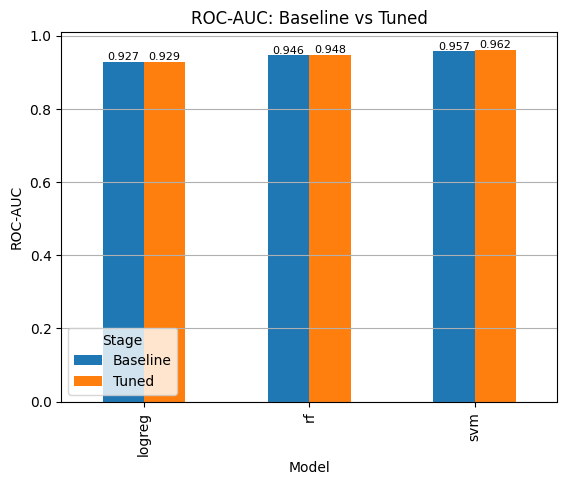

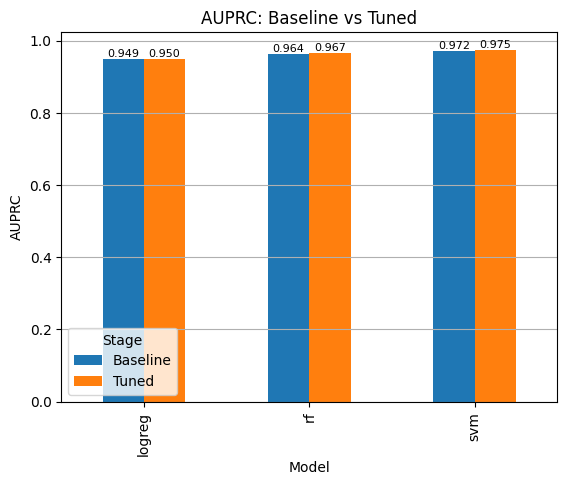

In [ ]:
# Plots: Baseline vs Tuned comparison
# ROC-AUC
pivot_roc = compare_df.pivot(index="Model", columns="Stage", values="ROC_AUC")
pt1= pivot_roc.plot(kind="bar")
for container in pt1.containers:
    pt1.bar_label(container, fmt="%.3f", padding=0, fontsize=8)
plt.title("ROC-AUC: Baseline vs Tuned")
plt.ylabel("ROC-AUC")
plt.grid(True, axis="y")
plt.show()

#AUPRC
pivot_pr = compare_df.pivot(index="Model", columns="Stage", values="AUPRC")
pt2= pivot_pr.plot(kind="bar")
for container in pt2.containers:
    pt2.bar_label(container, fmt="%.3f", padding=0, fontsize=8)
plt.title("AUPRC: Baseline vs Tuned")
plt.ylabel("AUPRC")
plt.grid(True, axis="y")
plt.show()


## **10)** Select best model and evaluate on held-out test scenarios

In [ ]:
# Pick best by cross-validated ROC-AUC
best_name = max(search_results, key=lambda k: search_results[k].best_score_)
best_gs = search_results[best_name]
best_model = best_gs.best_estimator_

print('|- Best model:', best_name, '-|\n')
print(' > Best CV ROC-AUC:', best_gs.best_score_)

# Probabilities on test set
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print('\n > Test ROC-AUC:', roc_auc_score(y_test, proba_test))
print('\n > Test PR-AUC:', average_precision_score(y_test, proba_test))
print('\n > Confusion matrix (thr=0.5):\n', confusion_matrix(y_test, pred_test))
print('\n > Classification report (thr=0.5):\n', classification_report(y_test, pred_test, digits=3))

|- Best model: rf -|

 > Best CV ROC-AUC: 0.940761475220986

 > Test ROC-AUC: 0.9480188767404916

 > Test PR-AUC: 0.9666818608705869

 > Confusion matrix (thr=0.5):
 [[141  33]
 [ 14 232]]

 > Classification report (thr=0.5):
               precision    recall  f1-score   support

           0      0.910     0.810     0.857       174
           1      0.875     0.943     0.908       246

    accuracy                          0.888       420
   macro avg      0.893     0.877     0.883       420
weighted avg      0.890     0.888     0.887       420



## **11)** Plots

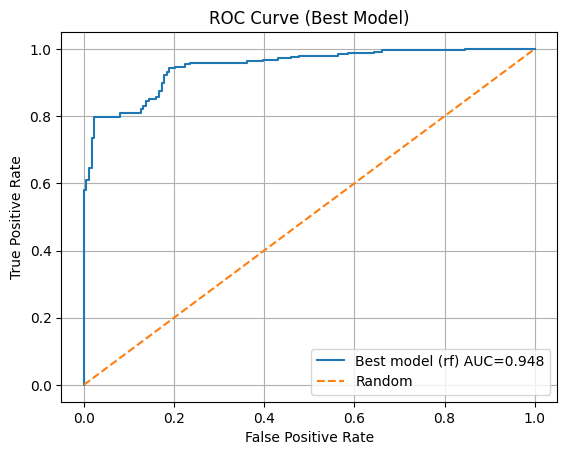

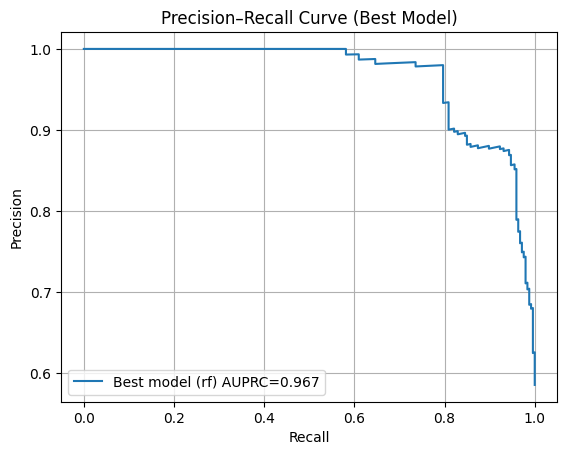

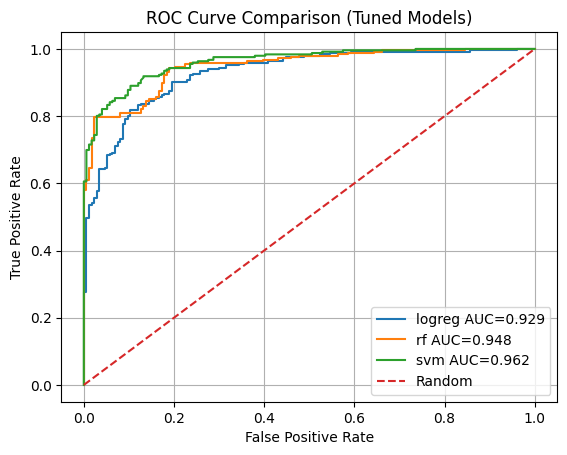

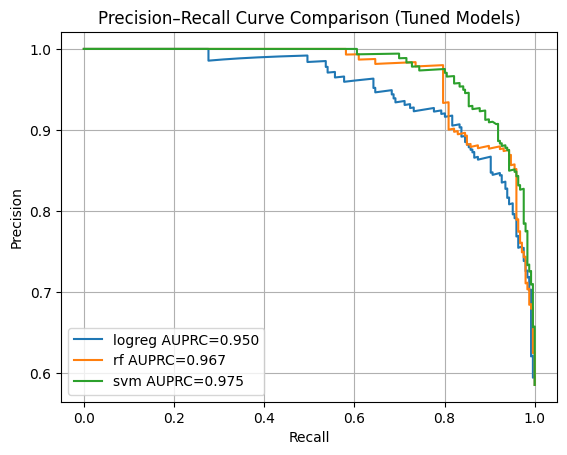

In [ ]:
# 1) Best model ROC curve
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Best model ({best_name}) AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Best Model)")
plt.legend()
plt.grid(True)
plt.show()

# 2) Best model PR curve
prec, rec, _ = precision_recall_curve(y_test, proba_test)
pr_auc = auc(rec, prec)

plt.figure()
plt.plot(rec, prec, label=f"Best model ({best_name}) AUPRC={pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Best Model)")
plt.legend()
plt.grid(True)
plt.show()

# 3) Tuned model ROC comparison
plt.figure()
for name, gs in search_results.items():
    tuned = gs.best_estimator_
    p = tuned.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc(fpr,tpr):.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Tuned Models)")
plt.legend()
plt.grid(True)
plt.show()

# 4) Tuned model PR comparison
plt.figure()
for name, gs in search_results.items():
    tuned = gs.best_estimator_
    p = tuned.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, p)
    plt.plot(rec, prec, label=f"{name} AUPRC={auc(rec,prec):.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (Tuned Models)")
plt.legend()
plt.grid(True)
plt.show()


## **12)** Ranking evaluation: Precision@5 per scenario
This is closer to the real product behavior: for each environmental scenario, rank crops and check if the top‑5 are truly suitable.

In [ ]:
def precision_at_k(y_true, y_score, k=5):
    # y_true: array of 0/1, y_score: probabilities
    order = np.argsort(-y_score)
    top = order[:k]
    if len(top) == 0:
        return np.nan
    return float(np.mean(y_true[top]))

# Evaluate P@5 per scenario in the test set
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['proba'] = proba_test
test_df['scenario_id'] = g_test.values

p5_list = []
for sid, chunk in test_df.groupby('scenario_id'):
    # Rank crops within this scenario
    p5 = precision_at_k(chunk['y_true'].to_numpy(), chunk['proba'].to_numpy(), k=5)
    p5_list.append(p5)

print('|- Scenarios evaluated ->', len(p5_list))
print('|- Mean Precision@5 ->', np.nanmean(p5_list))
print('|- Median Precision@5 ->', np.nanmedian(p5_list))

|- Scenarios evaluated -> 420
|- Mean Precision@5 -> 0.5857142857142857
|- Median Precision@5 -> 1.0


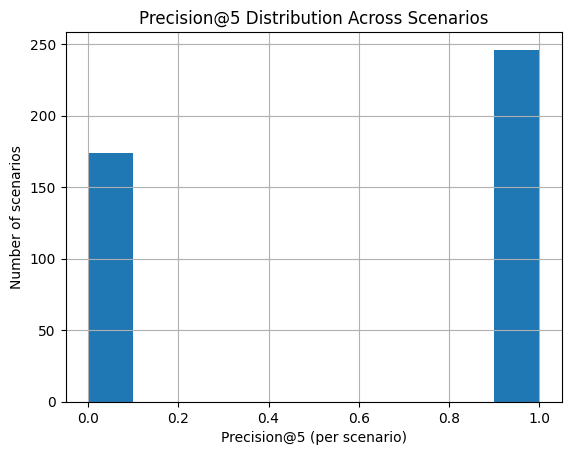

In [ ]:
# Plot: Distribution of Precision@5 across test scenarios (ranking quality)

_vals = [p for p in p5_list if p == p]  # filter NaNs
plt.figure()
plt.hist(_vals, bins=10)
plt.xlabel("Precision@5 (per scenario)")
plt.ylabel("Number of scenarios")
plt.title("Precision@5 Distribution Across Scenarios")
plt.grid(True)
plt.show()


## **13)** Derive crop requirement table (for inference)
Your earlier note: rooting depth is a **crop requirement**, so during inference we should assign it per crop.

We derive a stable value per crop from the training data (median).

In [ ]:
crop_req = (
    df.groupby('crop')['rooting_depth_m']
      .median()
      .reset_index()
      .rename(columns={'rooting_depth_m': 'rooting_depth_m_median'})
      .sort_values('crop')
)

display(crop_req.head())
print('Crops:', crop_req.shape[0])

,crop,rooting_depth_m_median
0,Banana,0.862379
1,Bitter Gourd,0.870126
2,Brinjal,0.900742
3,Capsicum,0.915210
4,Cucumber,0.848778


Crops: 21


## **14)** Save artifacts (model + crop requirements)
These files are what your backend / ranking notebook will load.

If you're in Colab and mounted Drive, change OUTPUT_DIR to your Drive folder.

In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/DSGP/artifacts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_ranking_model.joblib')
CROP_REQ_PATH = os.path.join(OUTPUT_DIR, 'crop_requirements_derived.csv')
META_PATH = os.path.join(OUTPUT_DIR, 'training_meta.json')

joblib.dump(best_model, MODEL_PATH)
crop_req.to_csv(CROP_REQ_PATH, index=False)

meta = {
    'best_model_name': best_name,
    'env_cols_for_grouping': ENV_COLS,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'threshold_default': 0.5
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
print('-', MODEL_PATH)
print('-', CROP_REQ_PATH)
print('-', META_PATH)

Saved:
- /content/drive/MyDrive/DSGP/artifacts/best_ranking_model.joblib
- /content/drive/MyDrive/DSGP/artifacts/crop_requirements_derived.csv
- /content/drive/MyDrive/DSGP/artifacts/training_meta.json


In [ ]:
# Keep a single artifact directory for both training and inference
ARTIFACT_DIR = OUTPUT_DIR

## **15)** Quick sanity: load model back and predict

In [ ]:
loaded = joblib.load(MODEL_PATH)
proba = loaded.predict_proba(X_test.head(10))[:,1]
print('Proba sample:', proba)

Proba sample: [0.54441967 0.68641042 0.2779035  0.63563975 0.6275162  0.57016819
 0.8579308  0.80628327 0.53841054 0.16264523]


#**Multi‑Crop Ranking — Inference & Top‑5 Recommendation**
This notebook loads the trained model artifacts and exposes a clean `rank_top5_crops(...)` function.

### Inputs
- Weather outputs (from Thirusha): temperature, rainfall, sunshine_hours (sunshine optional)
- Soil outputs (from Chamathka): ph, organic_carbon, cec, awc, bulk_density, texture_code

### Outputs
- Top‑5 crops with probability scores + class label (Suitable/Unsuitable)


## **0)** Colab setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install joblib pandas numpy scikit-learn

## **1)** Imports

In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
from IPython.display import display

## **2)** Load artifacts

In [ ]:
ARTIFACT_DIR = OUTPUT_DIR
MODEL_PATH = os.path.join(ARTIFACT_DIR, 'best_ranking_model.joblib')
CROP_REQ_PATH = os.path.join(ARTIFACT_DIR, 'crop_requirements_derived.csv')
META_PATH = os.path.join(ARTIFACT_DIR, 'training_meta.json')

model = joblib.load(MODEL_PATH)
crop_req = pd.read_csv(CROP_REQ_PATH)
with open(META_PATH, 'r') as f:
    meta = json.load(f)

print('Loaded model and crop requirements.')
display(crop_req.head())
print(meta)


Loaded model and crop requirements.


,crop,rooting_depth_m_median
0,Banana,0.862379
1,Bitter Gourd,0.870126
2,Brinjal,0.900742
3,Capsicum,0.915210
4,Cucumber,0.848778


{'best_model_name': 'rf', 'env_cols_for_grouping': ['temperature', 'rainfall', 'sunshine_hours', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code'], 'numeric_cols': ['temperature', 'rainfall', 'sunshine_hours', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'rooting_depth_m', 'texture_code'], 'categorical_cols': ['crop'], 'threshold_default': 0.5}


## **3)** Define the expected feature contract
These are the *minimum* required numeric keys coming from weather+soil modules.

If `sunshine_hours` is missing, we impute it using the training median stored below.

In [ ]:
REQUIRED_WEATHER = ['temperature', 'rainfall']            # sunshine_hours optional
OPTIONAL_WEATHER = ['sunshine_hours']

REQUIRED_SOIL = ['ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code']

# Fallback medians used only if Thirusha doesn't provide a value (e.g., sunshine_hours).
# Prefer using the already-loaded training dataframe (df) to avoid path issues.
TRAINING_FALLBACKS = {}

if 'df' in globals() and 'sunshine_hours' in df.columns:
    TRAINING_FALLBACKS['sunshine_hours'] = float(df['sunshine_hours'].median())
else:
    # Try local file if present
    if os.path.exists('Crop_training_data_FULL_1.csv'):
        _df_train = pd.read_csv('Crop_training_data_FULL_1.csv')
        TRAINING_FALLBACKS['sunshine_hours'] = float(_df_train['sunshine_hours'].median())
    else:
        # Safe neutral fallback (only used if sunshine_hours isn't provided)
        TRAINING_FALLBACKS['sunshine_hours'] = 0.0

print('Fallback sunshine_hours median:', TRAINING_FALLBACKS['sunshine_hours'])


Fallback sunshine_hours median: 7.481220244131389


## **4)** Helper: build per-crop query table

In [ ]:
def build_query_table(weather: dict, soil: dict, crop_req_df: pd.DataFrame) -> pd.DataFrame:
    # Validate required keys
    for k in REQUIRED_WEATHER:
        if k not in weather:
            raise ValueError(f'Missing weather key: {k}')
    for k in REQUIRED_SOIL:
        if k not in soil:
            raise ValueError(f'Missing soil key: {k}')

    sunshine = weather.get('sunshine_hours', None)
    if sunshine is None or (isinstance(sunshine, float) and np.isnan(sunshine)):
        # If unknown, set to a neutral fallback (you can improve later)
        sunshine = TRAINING_FALLBACKS.get('sunshine_hours', 0.0)

    base = {
        'temperature': float(weather['temperature']),
        'rainfall': float(weather['rainfall']),
        'sunshine_hours': float(sunshine),

        'ph': float(soil['ph']),
        'organic_carbon': float(soil['organic_carbon']),
        'cec': float(soil['cec']),
        'awc': float(soil['awc']),
        'bulk_density': float(soil['bulk_density']),
        'texture_code': float(soil['texture_code']),
    }

    # One row per crop, with crop-specific rooting depth (median derived from training)
    rows = []
    for _, r in crop_req_df.iterrows():
        row = base.copy()
        row['crop'] = r['crop']
        row['rooting_depth_m'] = float(r['rooting_depth_m_median'])
        rows.append(row)

    return pd.DataFrame(rows)

## **5)** Top‑5 ranking function (this is what your backend calls)

In [ ]:
def rank_top5_crops(weather: dict, soil: dict, top_k: int = 5, threshold: float = 0.5) -> pd.DataFrame:
    query_df = build_query_table(weather, soil, crop_req)

    # Predict probability of suitability for each crop
    probs = model.predict_proba(query_df)[:, 1]
    query_df['score'] = probs
    query_df['class'] = np.where(query_df['score'] >= threshold, 'Suitable', 'Unsuitable')

    out = query_df[['crop', 'score', 'class']].sort_values('score', ascending=False).head(top_k).reset_index(drop=True)
    return out

## **6)** Demo run

In [ ]:
# Example inputs
weather_example = {'temperature': 28.0, 'rainfall': 12.0, 'sunshine_hours': 6.5}
soil_example = {'ph': 6.2, 'organic_carbon': 1.8, 'cec': 12.5, 'awc': 0.18, 'bulk_density': 1.25, 'texture_code': 3}

top5 = rank_top5_crops(weather_example, soil_example, top_k=5, threshold=0.5)
display(top5)

,crop,score,class
0,Mangosteen,0.844393,Suitable
1,Pineapple,0.838646,Suitable
2,Passion Fruit,0.822940,Suitable
3,Banana,0.820669,Suitable
4,Manioc,0.810944,Suitable


## **-** What the soil component should output to support this ranking
Minimum soil payload keys required here:
- ph, organic_carbon, cec, awc, bulk_density, texture_code

Optionally you can add:
- soil cluster_id / soil_zone_name (for explanation), but the model does not require it.